# Dataset Analysis, my_dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install imagehash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.0 MB/s eta 0:00:00


In [3]:
import os
import random
import imagehash
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from matplotlib.patches import Patch

images_path = "/content/drive/MyDrive/4t/3r trimestre/Aprenentatge Profund/UPF_Deep_Learning_2026/Final Project/data/my_dataset/images"
labels_path = "/content/drive/MyDrive/4t/3r trimestre/Aprenentatge Profund/UPF_Deep_Learning_2026/Final Project/data/my_dataset/labels/labels_claradataset.csv"
# images_path = "/content/drive/MyDrive/UNI/UPF_Deep_Learning_2026/Final Project/data/my_dataset/images"
# labels_path = "/content/drive/MyDrive/UNI/UPF_Deep_Learning_2026/Final Project/data/my_dataset/labels/labels_claradataset.csv"

BRIGHT_THRESHOLD = 200
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
df_own = pd.read_csv(labels_path, header=None)
df_own.columns = ['filename', 'label']
df_own['filename'] = df_own['filename'].astype(str) + '.JPG'

print(df_own.head())
print(f"\nShape: {df_own.shape}")

       filename  label
0  IMG_6872.JPG      0
1  IMG_6873.JPG      0
2  IMG_6874.JPG      0
3  IMG_6875.JPG      0
4  IMG_6876.JPG      0

Shape: (1333, 2)


In [5]:
def load_all_stats_disk(df, images_path):
    """Compute per-image stats reading directly from disk."""
    results = []
    for i, row in df.iterrows():
        fpath = os.path.join(images_path, row['filename'])
        try:
            pixels = np.array(Image.open(fpath).convert('L')).flatten()
            results.append({
                'filename'    : row['filename'],
                'label'       : row['label'],
                'mean'        : pixels.mean(),
                'std'         : pixels.std(),
                'max'         : pixels.max(),
                'bright_ratio': (pixels > BRIGHT_THRESHOLD).sum() / len(pixels)
            })
        except Exception:
            pass
    return results

def load_images_disk(filenames, images_path):
    """Load list of images from disk as grayscale PIL."""
    imgs = []
    for fname in filenames:
        fpath = os.path.join(images_path, fname)
        imgs.append(Image.open(fpath).convert('L'))
    return imgs

def show_problem_grid_disk(df_subset, title, images_path, n=8):
    subset = df_subset.head(n)
    if len(subset) == 0:
        print(f"No images found for: {title}")
        return
    cols = min(len(subset), 4)
    rows = (len(subset) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    axes = np.array(axes).flatten()
    imgs = load_images_disk(subset['filename'].tolist(), images_path)
    for ax, (_, row), img in zip(axes, subset.iterrows(), imgs):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f"mean={row['mean']:.1f} std={row['std']:.1f}", fontsize=8)
        ax.set_xlabel(f"label={int(row['label'])}", fontsize=8, color='gray')
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[len(subset):]:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"myds_{title.replace(' ', '_')}.png", dpi=120, bbox_inches='tight')
    plt.show()

## Basic Statistics

In [7]:
total = len(df_own)
class_counts = df_own['label'].value_counts().sort_index()
class_names  = {0: 'No person', 1: 'Person'}


print("BASIC DATASET STATISTICS (my_dataset) \n")
print(f"\n Total images : {total}")
for label, count in class_counts.items():
    pct = 100 * count / total
    print(f"Class {label} ({class_names[label]}):  {count} images  ({pct:.1f}%)")

ratio = class_counts.max() / class_counts.min()
print(f"\n Class imbalance ratio : {ratio:.2f}x")
if ratio > 1.5:
    print("Class imbalance detected, consider class weighting or oversampling.")
else:
    print("Classes balanced.")

# Resolution distribution
print("\nRESOLUTION DISTRIBUTION")

resolutions = []
for fname in df_own['filename']:
    fpath = os.path.join(images_path, fname)
    try:
        with Image.open(fpath) as img:
            resolutions.append(img.size)
    except Exception:
        resolutions.append(None)
df_own['resolution'] = resolutions
res_counts = Counter(resolutions)
for res, count in sorted(r for r in res_counts.items() if r[0] is not None):
    print(f"  {res[0]}x{res[1]}  →  {count} images  ({100*count/total:.1f}%)")

# Dataset size
print("\n DATASET SIZE")

total_bytes = sum(
    os.path.getsize(os.path.join(images_path, f))
    for f in df_own['filename']
    if os.path.exists(os.path.join(images_path, f))
)
missing = df_own['filename'].apply(lambda f: not os.path.exists(os.path.join(images_path, f))).sum()
print(f"\n Total size on disk : {total_bytes / 1e6:.1f} MB")
if missing > 0:
    print(f"Missing files: {missing}")
else:
    print(f"All files found on disk.")

BASIC DATASET STATISTICS (my_dataset) 


 Total images : 1333
Class 0 (No person):  355 images  (26.6%)
Class 1 (Person):  978 images  (73.4%)

 Class imbalance ratio : 2.75x
Class imbalance detected, consider class weighting or oversampling.

RESOLUTION DISTRIBUTION
  320x240  →  1333 images  (100.0%)

 DATASET SIZE

 Total size on disk : 15.1 MB
All files found on disk.


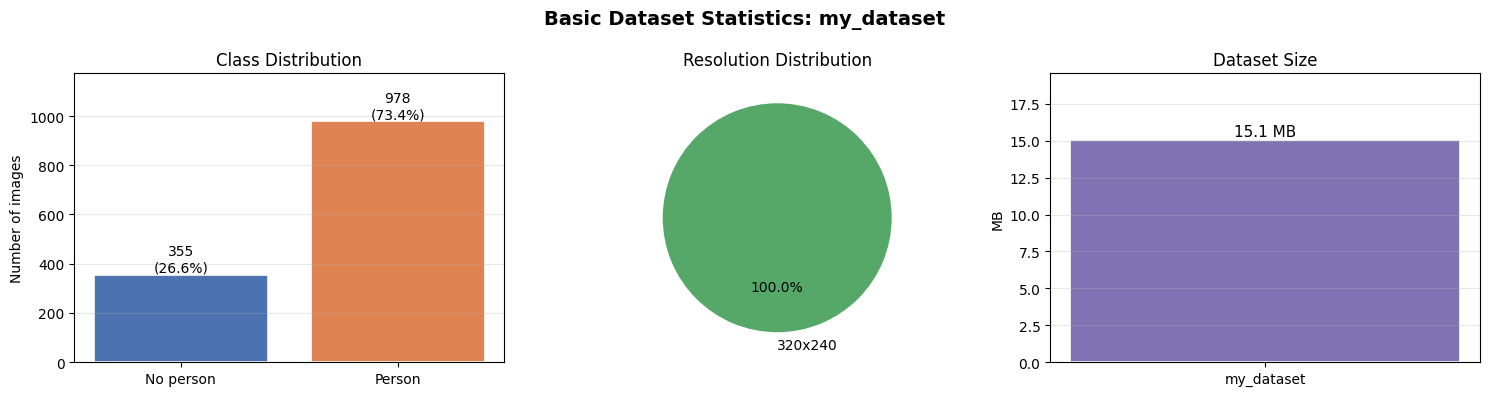

In [8]:
#PLOTS
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Basic Dataset Statistics: my_dataset", fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar([class_names[l] for l in class_counts.index], class_counts.values,
                    color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Number of images")
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val}\n({100*val/total:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, class_counts.max() * 1.2)
axes[0].grid(axis='y', alpha=0.3)

valid_res = {f"{k[0]}x{k[1]}": v for k, v in res_counts.items() if k is not None}
axes[1].pie(valid_res.values(), labels=valid_res.keys(), autopct='%1.1f%%',
            colors=['#55A868', '#C44E52'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Resolution Distribution")

axes[2].bar(['my_dataset'], [total_bytes / 1e6], color='#8172B3', edgecolor='white', linewidth=1.2)
axes[2].set_title("Dataset Size")
axes[2].set_ylabel("MB")
axes[2].text(0, total_bytes / 1e6 + 0.1, f"{total_bytes / 1e6:.1f} MB",
             ha='center', va='bottom', fontsize=11)
axes[2].set_ylim(0, (total_bytes / 1e6) * 1.3)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Compute Per-Image Stats

This cell computes mean, std, max and bright_ratio for every image.
Results are stored in `df_stats_own` and reused in all following sections.

In [9]:
print("Computing per-image stats...")
stats_own = load_all_stats_disk(df_own, images_path)
df_stats_own = pd.DataFrame(stats_own)
print(f"Done. {len(df_stats_own)} images processed.")
print(df_stats_own.describe())

Computing per-image stats...
Done. 1333 images processed.
             label         mean          std          max  bright_ratio
count  1333.000000  1333.000000  1333.000000  1333.000000   1333.000000
mean      0.733683    36.998335    37.975093   172.933983      0.005450
std       0.442198    18.647221    16.153937    51.336172      0.022629
min       0.000000     4.454167     8.504318    47.000000      0.000000
25%       0.000000    24.494740    25.672044   125.000000      0.000000
50%       1.000000    36.057773    36.221789   192.000000      0.000000
75%       1.000000    50.025339    49.641791   213.000000      0.000117
max       1.000000   111.771719   105.669747   237.000000      0.446589


## Visual Analysis

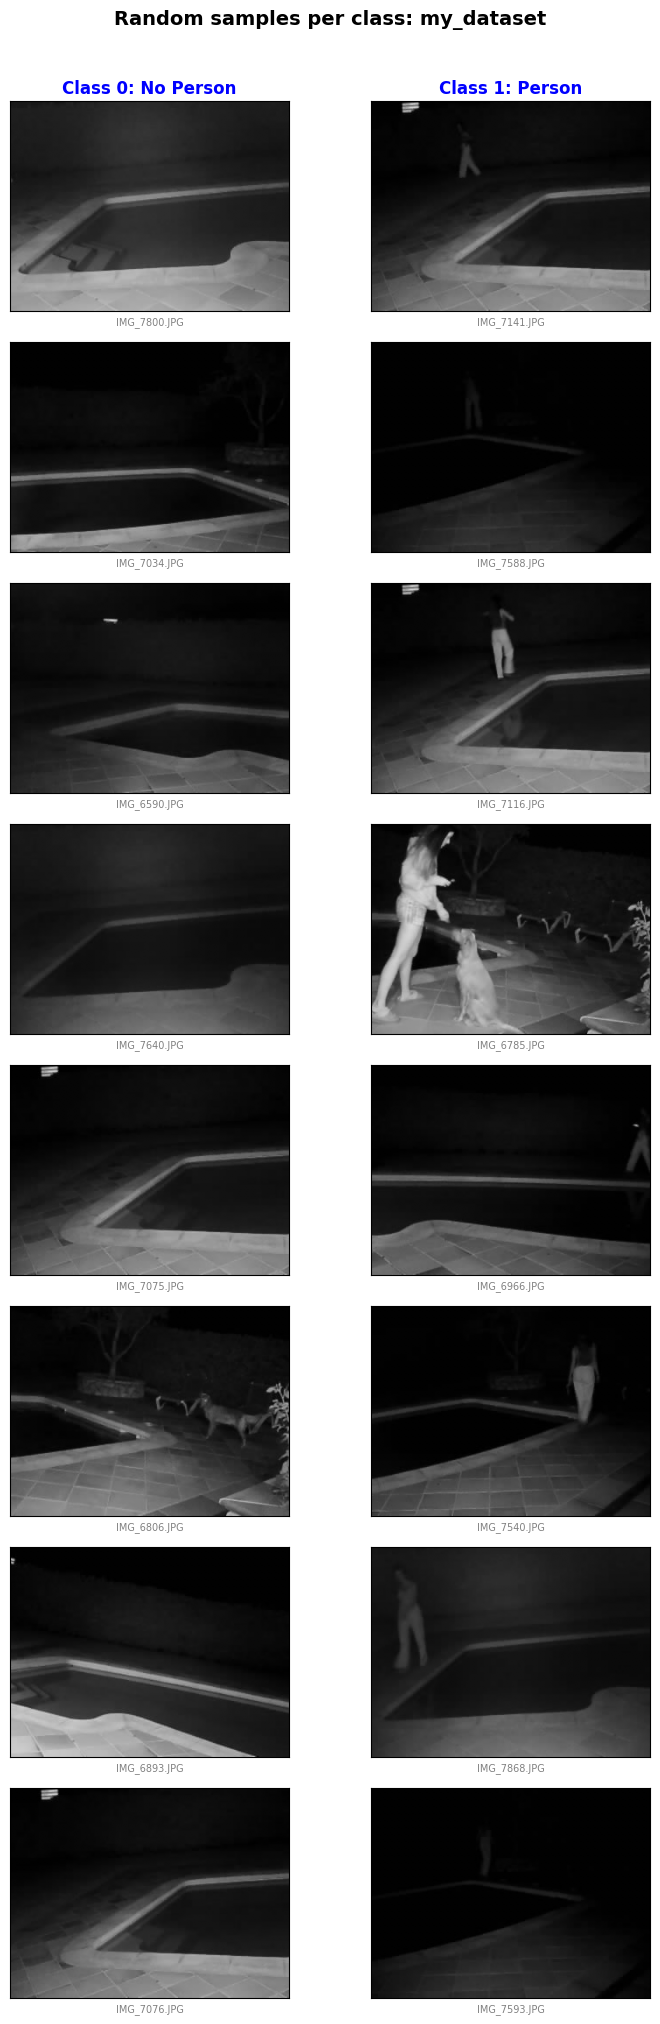

In [10]:
# Grid of random samples per class
N_SAMPLES = 8
samples_0 = df_own[df_own['label'] == 0]['filename'].sample(N_SAMPLES, random_state=SEED).tolist()
samples_1 = df_own[df_own['label'] == 1]['filename'].sample(N_SAMPLES, random_state=SEED).tolist()

imgs_0 = load_images_disk(samples_0, images_path)
imgs_1 = load_images_disk(samples_1, images_path)

fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(8, N_SAMPLES * 2.5))
fig.suptitle("Random samples per class: my_dataset", fontsize=14, fontweight='bold', y=1.01)

col_titles = ['Class 0: No Person', 'Class 1: Person']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold', color='blue')
for i, (img0, img1, f0, f1) in enumerate(zip(imgs_0, imgs_1, samples_0, samples_1)):
    for ax, img, fname in zip(axes[i], [img0, img1], [f0, f1]):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_xlabel(fname, fontsize=7, color='gray')
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

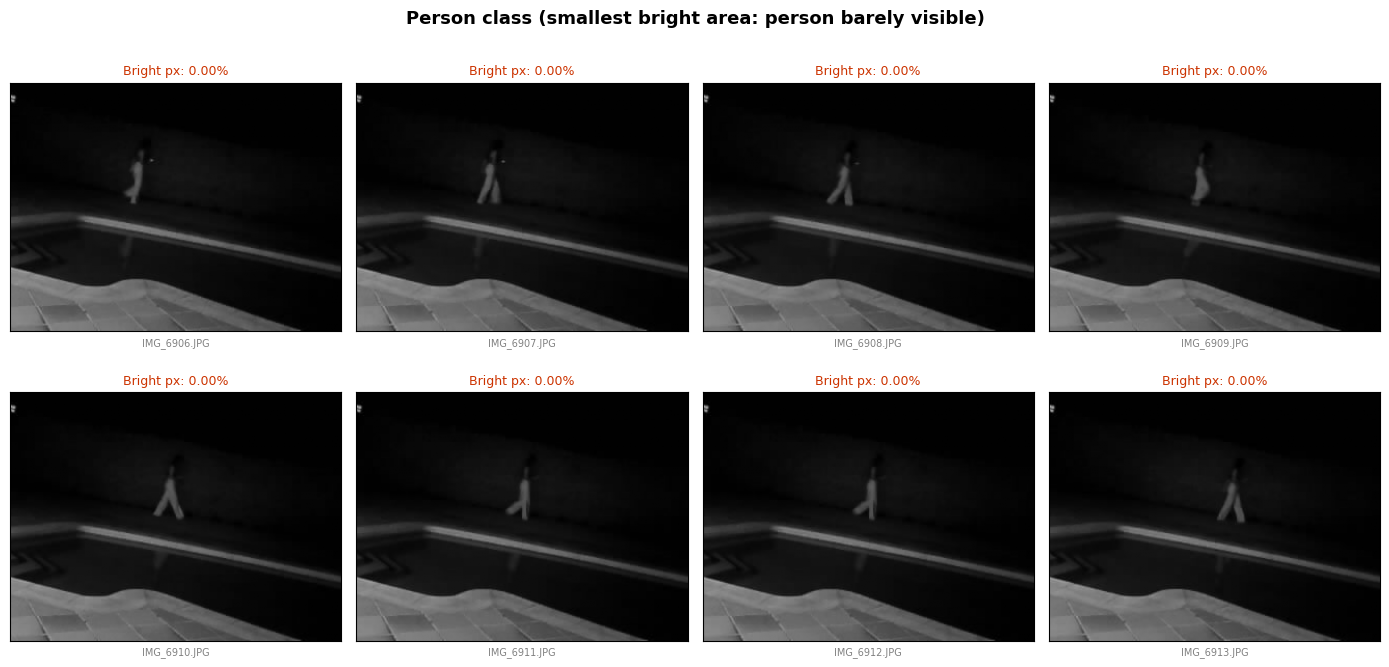

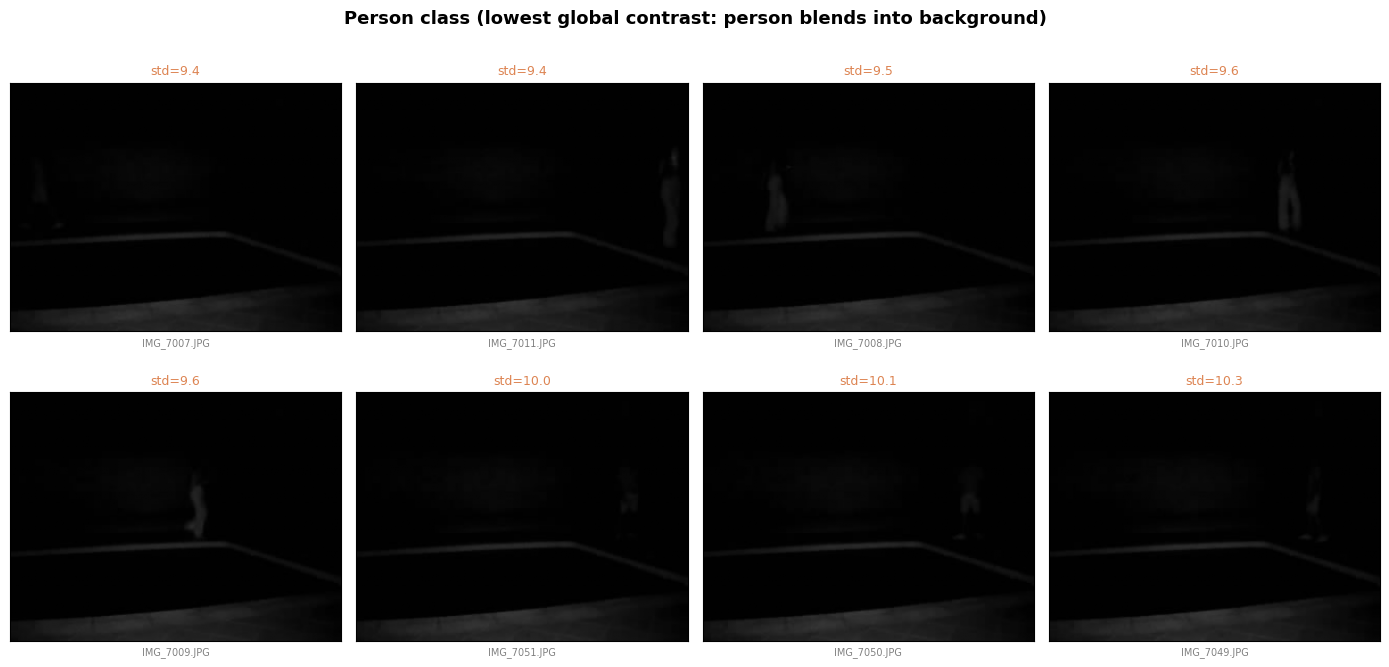

In [11]:
# Hardest images: small person and low contrast with class 1 only
N_HARD = 8

# smallest bright area
hardest_A = df_stats_own[df_stats_own['label'] == 1].nsmallest(N_HARD, 'bright_ratio')
imgs_A = load_images_disk(hardest_A['filename'].tolist(), images_path)
#plto
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Person class (smallest bright area: person barely visible)", fontsize=13, fontweight='bold')
for ax, row, img in zip(axes.flatten(), hardest_A.itertuples(), imgs_A):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"Bright px: {row.bright_ratio*100:.2f}%", fontsize=9, color='#CC3300')
    ax.set_xlabel(row.filename, fontsize=7, color='gray')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

#lowest global contrast (menys variació de pixels)
hardest_B = df_stats_own[df_stats_own['label'] == 1].nsmallest(N_HARD, 'std')
imgs_B = load_images_disk(hardest_B['filename'].tolist(), images_path)
#plot
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Person class (lowest global contrast: person blends into background)",
             fontsize=13, fontweight='bold')
for ax, row, img in zip(axes.flatten(), hardest_B.itertuples(), imgs_B):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"std={row.std:.1f}", fontsize=9, color='#DD8452')
    ax.set_xlabel(row.filename, fontsize=7, color='gray')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


  Mean: Class 0: 41.93  |  Class 1: 35.21
  Difference of means   : 6.73
  Separability index d' : 0.147
  Low separability.


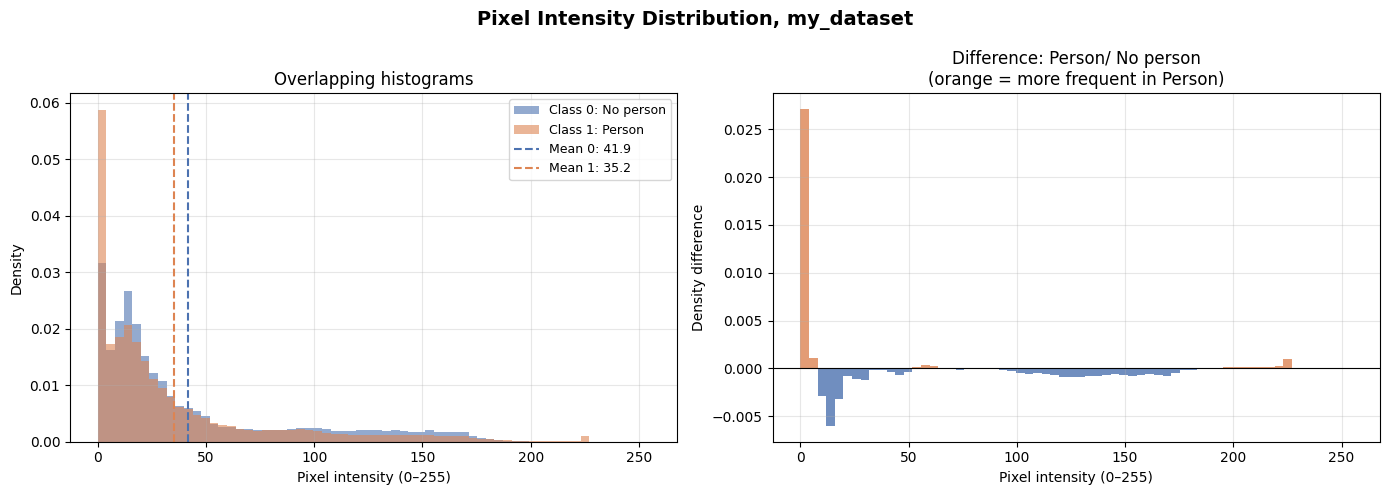

In [12]:
# Pixel intensity histogram per class
# N_SAMPLE_HIST = 100

# sample_0 = df_stats_own[df_stats_own['label'] == 0].sample(N_SAMPLE_HIST, random_state=SEED)['filename'].tolist()
# sample_1 = df_stats_own[df_stats_own['label'] == 1].sample(N_SAMPLE_HIST, random_state=SEED)['filename'].tolist()

#try all fotos
sample_0 = df_stats_own[df_stats_own['label'] == 0]['filename'].tolist()
sample_1 = df_stats_own[df_stats_own['label'] == 1]['filename'].tolist()

#extreure tots els pixels
pixels_0 = np.concatenate([
    np.array(Image.open(os.path.join(images_path, f)).convert('L')).flatten()
    for f in sample_0])
pixels_1 = np.concatenate([
    np.array(Image.open(os.path.join(images_path, f)).convert('L')).flatten()
    for f in sample_1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pixel Intensity Distribution, my_dataset", fontsize=14, fontweight='bold')
BINS = 64

mean_0, mean_1 = pixels_0.mean(), pixels_1.mean()
axes[0].hist(pixels_0, bins=BINS, range=(0,255), density=True,
             alpha=0.6, color='#4C72B0', label='Class 0: No person')
axes[0].hist(pixels_1, bins=BINS, range=(0,255), density=True,
             alpha=0.6, color='#DD8452', label='Class 1: Person')
axes[0].axvline(mean_0, color='#4C72B0', linestyle='--', linewidth=1.5, label=f'Mean 0: {mean_0:.1f}')
axes[0].axvline(mean_1, color='#DD8452', linestyle='--', linewidth=1.5, label=f'Mean 1: {mean_1:.1f}')
axes[0].set_xlabel("Pixel intensity (0–255)")
axes[0].set_ylabel("Density")
axes[0].set_title("Overlapping histograms")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

hist_0, edges = np.histogram(pixels_0, bins=BINS, range=(0,255), density=True)
hist_1, _     = np.histogram(pixels_1, bins=BINS, range=(0,255), density=True)
centers = (edges[:-1] + edges[1:]) / 2
diff = hist_1 - hist_0
axes[1].bar(centers, diff, width=(255/BINS),
            color=np.where(diff >= 0, '#DD8452', '#4C72B0'), alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel("Pixel intensity (0–255)")
axes[1].set_ylabel("Density difference")
axes[1].set_title("Difference: Person/ No person\n(orange = more frequent in Person)")
axes[1].grid(alpha=0.3)

separability = abs(mean_1 - mean_0) / ((pixels_0.std() + pixels_1.std()) / 2)
print(f"\n  Mean: Class 0: {mean_0:.2f}  |  Class 1: {mean_1:.2f}")
print(f"  Difference of means   : {abs(mean_1 - mean_0):.2f}")
print(f"  Separability index d' : {separability:.3f}")
print(" Meaningful separation." if separability > 0.5 else "  Low separability.")

plt.tight_layout()
plt.show()

## Intensity Analysis

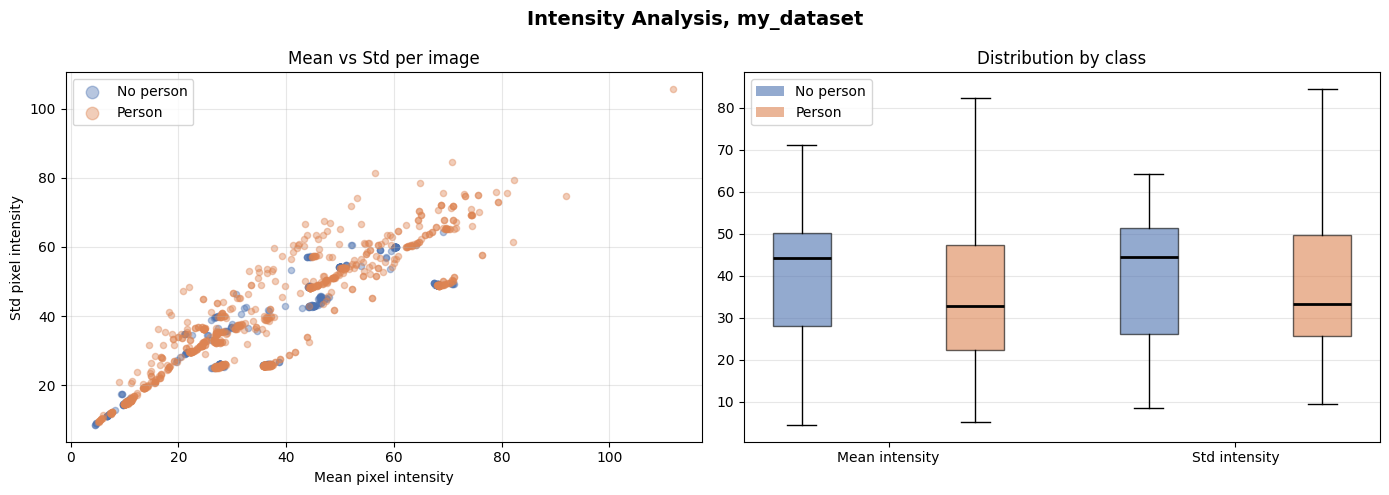

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Intensity Analysis, my_dataset", fontsize=14, fontweight='bold')

colors_map = {0: '#4C72B0', 1: '#DD8452'}
labels_map = {0: 'No person', 1: 'Person'}

# Scatter mean vs std
for label in [0, 1]:
    subset = df_stats_own[df_stats_own['label'] == label]
    axes[0].scatter(subset['mean'], subset['std'],
                    alpha=0.4, s=20, color=colors_map[label], label=labels_map[label])
axes[0].set_xlabel("Mean pixel intensity")
axes[0].set_ylabel("Std pixel intensity")
axes[0].set_title("Mean vs Std per image")
axes[0].legend(fontsize=10, markerscale=2)
axes[0].grid(alpha=0.3)

# Boxplots
data_mean = [df_stats_own[df_stats_own['label']==0]['mean'].values,
             df_stats_own[df_stats_own['label']==1]['mean'].values]
data_std  = [df_stats_own[df_stats_own['label']==0]['std'].values,
             df_stats_own[df_stats_own['label']==1]['std'].values]

bp1 = axes[1].boxplot(data_mean, positions=[1, 2.5], widths=0.5,
                      patch_artist=True, showfliers=False,
                      medianprops=dict(color='black', linewidth=2))
bp1['boxes'][0].set_facecolor('#4C72B0')
bp1['boxes'][0].set_alpha(0.6)
bp1['boxes'][1].set_facecolor('#DD8452')
bp1['boxes'][1].set_alpha(0.6)

bp2 = axes[1].boxplot(data_std, positions=[4, 5.5], widths=0.5,
                      patch_artist=True, showfliers=False,
                      medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor('#4C72B0')
bp2['boxes'][0].set_alpha(0.6)
bp2['boxes'][1].set_facecolor('#DD8452')
bp2['boxes'][1].set_alpha(0.6)

axes[1].set_xticks([1.75, 4.75])
axes[1].set_xticklabels(['Mean intensity', 'Std intensity'])
axes[1].set_title("Distribution by class")
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(handles=[Patch(facecolor='#4C72B0', alpha=0.6, label='No person'),
                         Patch(facecolor='#DD8452', alpha=0.6, label='Person')], fontsize=10)

plt.tight_layout()
plt.show()

Done. Class 0: 355 images  |  Class 1: 978 images


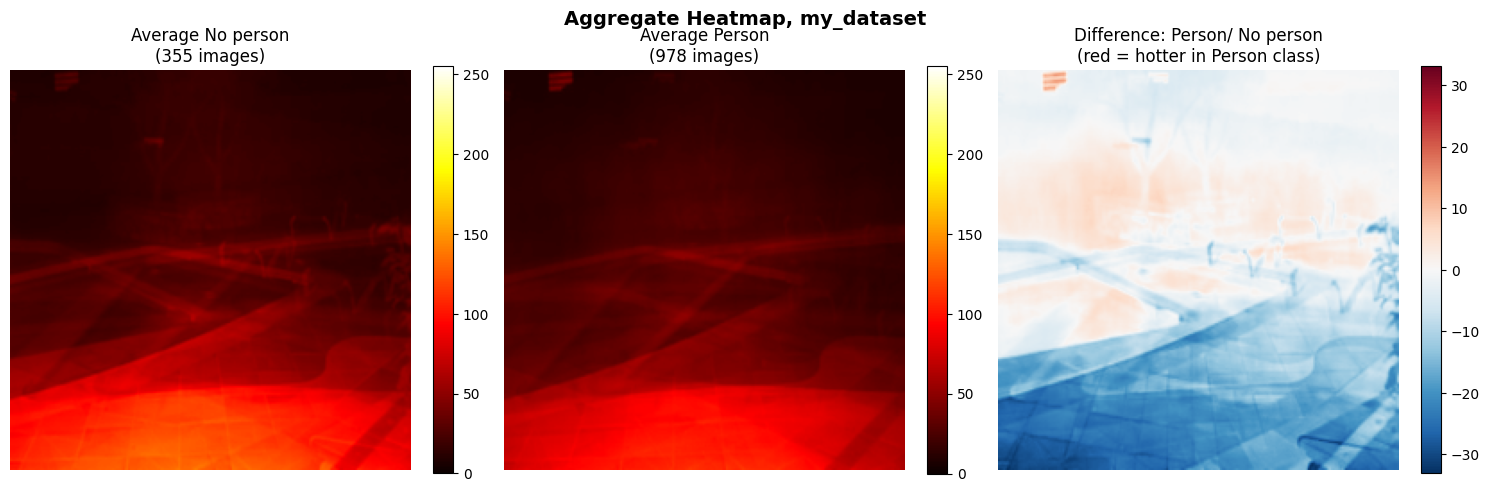

In [16]:
# Aggregate heatmap per class
TARGET_SIZE = (224, 224)
acc_0 = np.zeros(TARGET_SIZE, dtype=np.float64)
acc_1 = np.zeros(TARGET_SIZE, dtype=np.float64)
count_0, count_1 = 0, 0

for _, row in df_own.iterrows():
    fpath = os.path.join(images_path, row['filename'])
    try:
        img = np.array(Image.open(fpath).convert('L').resize(TARGET_SIZE), dtype=np.float64)
        if row['label'] == 0:
            acc_0 += img; count_0 += 1
        else:
            acc_1 += img; count_1 += 1
    except Exception:
        pass

avg_0 = acc_0 / count_0
avg_1 = acc_1 / count_1
diff  = avg_1 - avg_0
print(f"Done. Class 0: {count_0} images  |  Class 1: {count_1} images")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Aggregate Heatmap, my_dataset", fontsize=14, fontweight='bold')

im0 = axes[0].imshow(avg_0, cmap='hot', vmin=0, vmax=255)
axes[0].set_title(f"Average No person\n({count_0} images)")
axes[0].axis('off'); plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(avg_1, cmap='hot', vmin=0, vmax=255)
axes[1].set_title(f"Average Person\n({count_1} images)")
axes[1].axis('off'); plt.colorbar(im1, ax=axes[1], fraction=0.046)

vmax = np.abs(diff).max()
imd = axes[2].imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[2].set_title("Difference: Person/ No person\n(red = hotter in Person class)")
axes[2].axis('off'); plt.colorbar(imd, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## Problem Detection

In [18]:
# Corrupt / empty images
BLACK_MAX_THRESH  = 5
WHITE_MEAN_THRESH = 250
LOW_STD_THRESH    = 2

black = df_stats_own[df_stats_own['max']  < BLACK_MAX_THRESH]
white = df_stats_own[df_stats_own['mean'] > WHITE_MEAN_THRESH]
flat  = df_stats_own[(df_stats_own['std'] < LOW_STD_THRESH) &
                     (df_stats_own['max'] >= BLACK_MAX_THRESH) &
                     (df_stats_own['mean'] <= WHITE_MEAN_THRESH)]


print("CORRUPT / PROBLEMATIC IMAGES")
print(f"Totally black: {len(black)} images")
print(f"Totally white: {len(white)} images")
print(f"Near-flat: {len(flat)} images")
print(f"Total affected: {len(black)+len(white)+len(flat)} ({100*(len(black)+len(white)+len(flat))/len(df_stats_own):.2f}%)")


CORRUPT / PROBLEMATIC IMAGES
Totally black: 0 images
Totally white: 0 images
Near-flat: 0 images
Total affected: 0 (0.00%)


In [20]:
# Perceptual hashing, near-duplicate detection
print("Computing perceptual hashes...")
hashes_own = {}
for fname in df_own['filename']:
    fpath = os.path.join(images_path, fname)
    try:
        hashes_own[fname] = imagehash.phash(Image.open(fpath).convert('L'), hash_size=8)
    except Exception:
        pass
print(f"Done. {len(hashes_own)} hashes computed.")

hash_list = [(f, h) for f, h in hashes_own.items()]
visited, dup_groups_own = set(), []
for i, (fi, hi) in enumerate(hash_list):
    if fi in visited: continue
    group = [fi]
    for fj, hj in hash_list[i+1:]:
        if fj not in visited and (hi - hj) <= 5:
            group.append(fj); visited.add(fj)
    if len(group) > 1:
        visited.add(fi); dup_groups_own.append(group)

total_dup = sum(len(g) for g in dup_groups_own)
print(f"\nDuplicate groups found: {len(dup_groups_own)}")
print(f"Images affected: {total_dup} ({100*total_dup/len(df_own):.1f}%)")
print(f"Largest group size: {max((len(g) for g in dup_groups_own), default=0)}")


Computing perceptual hashes...
Done. 1333 hashes computed.

Duplicate groups found: 174
Images affected: 1081 (81.1%)
Largest group size: 92


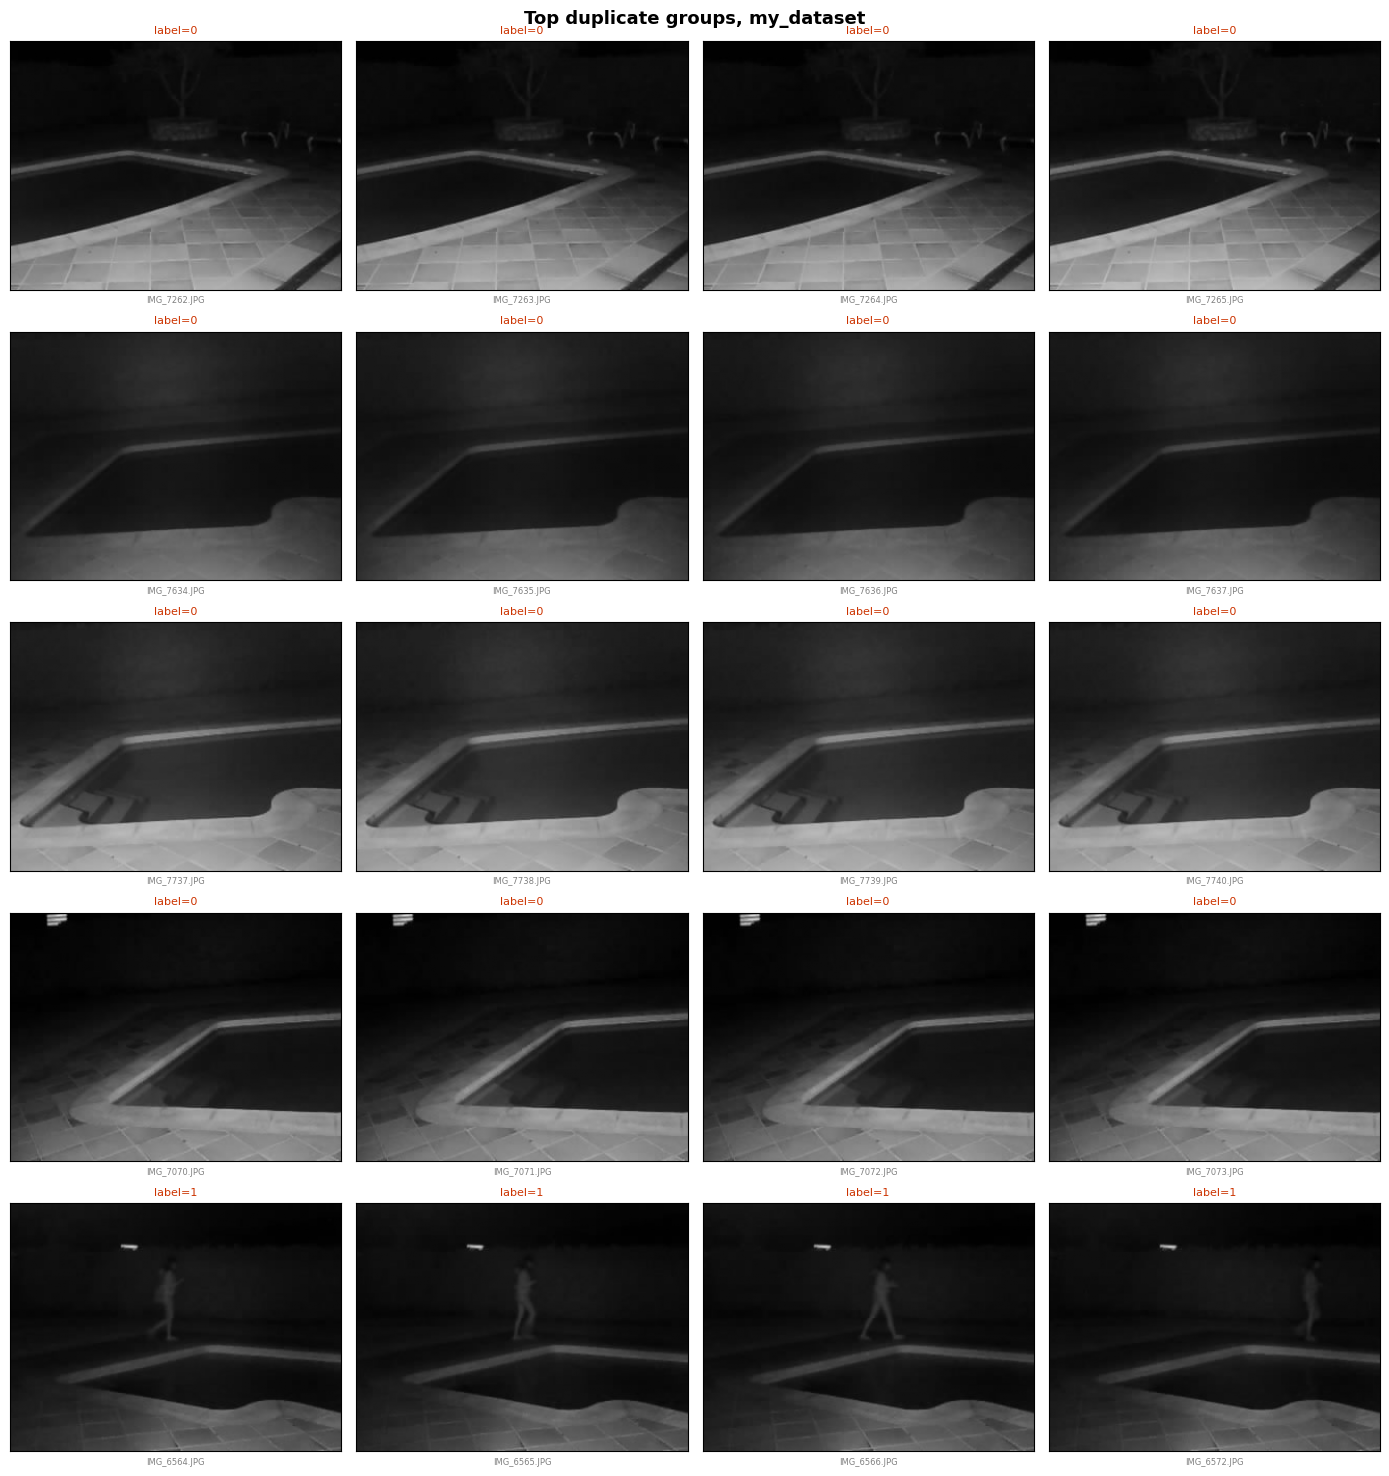


Dubious labels (class 1, barely detectable): 87


In [22]:
# Show top duplicate groups
top_groups = sorted(dup_groups_own, key=len, reverse=True)[:5]

if top_groups:
    n_rows = len(top_groups)
    fig, axes = plt.subplots(n_rows, 4, figsize=(14, n_rows * 3))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle("Top duplicate groups, my_dataset", fontsize=13, fontweight='bold')

    for row_i, group in enumerate(top_groups):
        samples = group[:4]
        imgs    = load_images_disk(samples, images_path)
        for col_i, (fname, img) in enumerate(zip(samples, imgs)):
            ax = axes[row_i][col_i]
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)
            label = df_own[df_own['filename'] == fname]['label'].values[0]
            ax.set_title(f"label={label}", fontsize=8, color='#CC3300')
            ax.set_xlabel(fname, fontsize=6, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
        for col_i in range(len(samples), 4):
            axes[row_i][col_i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(" No duplicate groups to display.")

#Dubious labels
dubious = df_stats_own[
    (df_stats_own['label'] == 1) &
    (df_stats_own['bright_ratio'] < 0.005) &
    (df_stats_own['std'] < 15.0)
]
print(f"\nDubious labels (class 1, barely detectable): {len(dubious)}")
